In [1]:
import pandas as pd
import numpy as np

In [2]:
climate_df = pd.read_csv('datasets/raw_climate_data.csv')

In [3]:
climate_df["Temp_max"] = climate_df["T2M_MAX"]
climate_df["Temp_min"] = climate_df["T2M_MIN"]
climate_df["Rainfall"] = climate_df["PRECTOTCORR"]
climate_df["Humidity"] = climate_df["RH2M"]
climate_df["Soil_pH"] = climate_df["Soil_pH_0_5cm"]

In [4]:
climate_df = climate_df[["County", "Date", "Temp_max", "Temp_min", "Rainfall", "Humidity", "Soil_pH"]]

In [5]:
climate_df.isna().sum()

County      0
Date        0
Temp_max    0
Temp_min    0
Rainfall    0
Humidity    0
Soil_pH     0
dtype: int64

In [6]:
climate_df

,County,Date,Temp_max,Temp_min,Rainfall,Humidity,Soil_pH
0,mombasa,2010-01-01,34.38,23.11,0.45,71.63,6.266667
1,mombasa,2010-01-02,34.48,23.29,2.17,72.44,6.266667
2,mombasa,2010-01-03,32.05,23.79,1.89,75.17,6.266667
3,mombasa,2010-01-04,34.33,23.96,0.39,70.45,6.266667
4,mombasa,2010-01-05,35.09,23.48,1.44,70.43,6.266667
...,...,...,...,...,...,...,...
257508,nairobi,2024-12-27,27.77,14.79,0.14,69.84,6.225000
257509,nairobi,2024-12-28,27.24,14.91,0.07,68.94,6.225000
257510,nairobi,2024-12-29,28.55,13.60,0.01,64.06,6.225000
257511,nairobi,2024-12-30,28.04,13.93,0.05,65.32,6.225000


In [7]:
crop_prices_df = pd.read_csv('datasets/raw_crop_data.csv')

In [9]:
crop_prices_df["County"] = crop_prices_df["County"].str.strip().str.lower()

In [10]:
crop_prices_df["Wholesale"].isna().sum()
crop_prices_df["Wholesale"] = crop_prices_df["Wholesale"].fillna(crop_prices_df["Wholesale"].mean())
crop_prices_df["Wholesale"].isna().sum()

np.int64(0)

In [11]:
crop_prices_df["Retail"].isna().sum()
crop_prices_df["Retail"] = crop_prices_df["Retail"].fillna(crop_prices_df["Retail"].mean())
crop_prices_df["Retail"].isna().sum()

np.int64(0)

In [12]:
crop_prices_df["Crop"] = crop_prices_df["Commodity"]

In [13]:
crop_prices_df = crop_prices_df[["County", "Crop", "Wholesale", "Retail","Date"]] 

In [14]:
crop_prices_df

,County,Crop,Wholesale,Retail,Date
0,kwale,Tomatoes,80.000000,100.000000,2026-03-03
1,trans-nzoia,Tomatoes,60.000000,80.000000,2026-03-03
2,taita-taveta,Tomatoes,65.192076,60.000000,2026-03-03
3,taita-taveta,Tomatoes,60.000000,99.084886,2026-03-03
4,taita-taveta,Tomatoes,60.000000,99.084886,2026-03-03
...,...,...,...,...,...
18186,bungoma,Dry Onions,90.000000,100.000000,2024-06-21
18187,kitui,Dry Onions,130.000000,180.000000,2024-06-21
18188,kilifi,Dry Onions,233.330000,200.000000,2024-06-21
18189,trans-nzoia,Dry Onions,150.000000,200.000000,2024-06-21


In [15]:
merged_df = pd.merge(
    crop_prices_df,
    climate_df,
    on=["County", "Date"],
    how="inner"
)

In [16]:
merged_df

,County,Crop,Wholesale,Retail,Date,Temp_max,Temp_min,Rainfall,Humidity,Soil_pH
0,nairobi,Tomatoes,65.192076,70.0,2024-11-18,27.68,16.09,0.59,73.36,6.225
1,nairobi,Tomatoes,60.000000,80.0,2024-11-11,24.60,16.82,3.84,77.97,6.225
2,nairobi,Tomatoes,65.192076,120.0,2024-11-08,28.66,16.12,1.79,65.83,6.225
3,nairobi,Tomatoes,65.192076,70.0,2024-11-06,28.95,16.27,4.48,70.78,6.225
4,nairobi,Tomatoes,65.192076,80.0,2024-10-16,31.35,15.55,0.08,51.22,6.225
...,...,...,...,...,...,...,...,...,...,...
7672,kirinyaga,Dry Onions,80.000000,130.0,2024-06-21,24.20,14.30,1.00,80.98,5.900
7673,bungoma,Dry Onions,90.000000,100.0,2024-06-21,27.31,17.20,2.70,73.73,5.450
7674,kitui,Dry Onions,130.000000,180.0,2024-06-21,29.70,17.76,0.43,69.69,6.400
7675,kilifi,Dry Onions,233.330000,200.0,2024-06-21,28.07,25.10,1.65,76.14,6.300


In [17]:
merged_df.isna().sum()

County       0
Crop         0
Wholesale    0
Retail       0
Date         0
Temp_max     0
Temp_min     0
Rainfall     0
Humidity     0
Soil_pH      0
dtype: int64

In [18]:
# Date decomposition
import pandas as pd

# Ensure your Date column is in the correct datetime format
merged_df['Date'] = pd.to_datetime(merged_df['Date'])

# Extract Year, Month, and Day
merged_df['Year'] = merged_df['Date'].dt.year
merged_df['Month'] = merged_df['Date'].dt.month
merged_df['Day'] = merged_df['Date'].dt.day

# Optional: Extract the Quarter (useful for seasonal financial trends)
merged_df['Quarter'] = merged_df['Date'].dt.quarter

In [19]:
merged_df

,County,Crop,Wholesale,Retail,Date,Temp_max,Temp_min,Rainfall,Humidity,Soil_pH,Year,Month,Day,Quarter
0,nairobi,Tomatoes,65.192076,70.0,2024-11-18,27.68,16.09,0.59,73.36,6.225,2024,11,18,4
1,nairobi,Tomatoes,60.000000,80.0,2024-11-11,24.60,16.82,3.84,77.97,6.225,2024,11,11,4
2,nairobi,Tomatoes,65.192076,120.0,2024-11-08,28.66,16.12,1.79,65.83,6.225,2024,11,8,4
3,nairobi,Tomatoes,65.192076,70.0,2024-11-06,28.95,16.27,4.48,70.78,6.225,2024,11,6,4
4,nairobi,Tomatoes,65.192076,80.0,2024-10-16,31.35,15.55,0.08,51.22,6.225,2024,10,16,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7672,kirinyaga,Dry Onions,80.000000,130.0,2024-06-21,24.20,14.30,1.00,80.98,5.900,2024,6,21,2
7673,bungoma,Dry Onions,90.000000,100.0,2024-06-21,27.31,17.20,2.70,73.73,5.450,2024,6,21,2
7674,kitui,Dry Onions,130.000000,180.0,2024-06-21,29.70,17.76,0.43,69.69,6.400,2024,6,21,2
7675,kilifi,Dry Onions,233.330000,200.0,2024-06-21,28.07,25.10,1.65,76.14,6.300,2024,6,21,2


In [20]:
# # price spread - profitability analysis
# # Calculate the absolute difference
# merged_df['Price_Spread'] = merged_df['Retail'] - merged_df['Wholesale']

# # Calculate the Percentage Margin (often more useful for comparison across different crops)
# # Formula: (Retail - Wholesale) / Wholesale
# merged_df['Price_Margin_Pct'] = (merged_df['Price_Spread'] / merged_df['Wholesale']) * 100

# Calculate the average ratio from 'healthy' tomato rows
healthy_tomatoes = merged_df[(merged_df['Crop'] == 'Tomatoes') & (merged_df['Wholesale'] < merged_df['Retail'])]
avg_ratio = (healthy_tomatoes['Wholesale'] / healthy_tomatoes['Retail']).mean()

# Apply this ratio to the 'broken' rows
mask = (merged_df['Crop'] == 'Tomatoes') & (merged_df['Wholesale'] >= merged_df['Retail'])
merged_df.loc[mask, 'Wholesale'] = merged_df.loc[mask, 'Retail'] * avg_ratio

# Recalculate your features
merged_df['Price_Spread'] = merged_df['Retail'] - merged_df['Wholesale']
merged_df['Price_Margin_Pct'] = (merged_df['Price_Spread'] / merged_df['Wholesale']) * 100

In [21]:
merged_df

,County,Crop,Wholesale,Retail,Date,Temp_max,Temp_min,Rainfall,Humidity,Soil_pH,Year,Month,Day,Quarter,Price_Spread,Price_Margin_Pct
0,nairobi,Tomatoes,65.192076,70.0,2024-11-18,27.68,16.09,0.59,73.36,6.225,2024,11,18,4,4.807924,7.375013
1,nairobi,Tomatoes,60.000000,80.0,2024-11-11,24.60,16.82,3.84,77.97,6.225,2024,11,11,4,20.000000,33.333333
2,nairobi,Tomatoes,65.192076,120.0,2024-11-08,28.66,16.12,1.79,65.83,6.225,2024,11,8,4,54.807924,84.071450
3,nairobi,Tomatoes,65.192076,70.0,2024-11-06,28.95,16.27,4.48,70.78,6.225,2024,11,6,4,4.807924,7.375013
4,nairobi,Tomatoes,65.192076,80.0,2024-10-16,31.35,15.55,0.08,51.22,6.225,2024,10,16,4,14.807924,22.714300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7672,kirinyaga,Dry Onions,80.000000,130.0,2024-06-21,24.20,14.30,1.00,80.98,5.900,2024,6,21,2,50.000000,62.500000
7673,bungoma,Dry Onions,90.000000,100.0,2024-06-21,27.31,17.20,2.70,73.73,5.450,2024,6,21,2,10.000000,11.111111
7674,kitui,Dry Onions,130.000000,180.0,2024-06-21,29.70,17.76,0.43,69.69,6.400,2024,6,21,2,50.000000,38.461538
7675,kilifi,Dry Onions,233.330000,200.0,2024-06-21,28.07,25.10,1.65,76.14,6.300,2024,6,21,2,-33.330000,-14.284490


In [22]:
from sklearn.preprocessing import LabelEncoder

# Initialize encoders
county_encoder = LabelEncoder()
crop_encoder = LabelEncoder()

# Fit and transform the columns
merged_df['County_Encoded'] = county_encoder.fit_transform(merged_df['County'])
merged_df['Crop_Encoded'] = crop_encoder.fit_transform(merged_df['Crop'])

# Create mapping dictionaries for later use (Decoding)
county_mapping = dict(zip(county_encoder.classes_, county_encoder.transform(county_encoder.classes_)))
crop_mapping = dict(zip(crop_encoder.classes_, crop_encoder.transform(crop_encoder.classes_)))

print("Crop Mapping:", crop_mapping)

Crop Mapping: {'Coffee': np.int64(0), 'Dry Maize': np.int64(1), 'Dry Onions': np.int64(2), 'Kales/Sukuma Wiki': np.int64(3), 'Rice': np.int64(4), 'Tea': np.int64(5), 'Tomatoes': np.int64(6), 'Wheat': np.int64(7)}


In [23]:
merged_df

,County,Crop,Wholesale,Retail,Date,Temp_max,Temp_min,Rainfall,Humidity,Soil_pH,Year,Month,Day,Quarter,Price_Spread,Price_Margin_Pct,County_Encoded,Crop_Encoded
0,nairobi,Tomatoes,65.192076,70.0,2024-11-18,27.68,16.09,0.59,73.36,6.225,2024,11,18,4,4.807924,7.375013,26,6
1,nairobi,Tomatoes,60.000000,80.0,2024-11-11,24.60,16.82,3.84,77.97,6.225,2024,11,11,4,20.000000,33.333333,26,6
2,nairobi,Tomatoes,65.192076,120.0,2024-11-08,28.66,16.12,1.79,65.83,6.225,2024,11,8,4,54.807924,84.071450,26,6
3,nairobi,Tomatoes,65.192076,70.0,2024-11-06,28.95,16.27,4.48,70.78,6.225,2024,11,6,4,4.807924,7.375013,26,6
4,nairobi,Tomatoes,65.192076,80.0,2024-10-16,31.35,15.55,0.08,51.22,6.225,2024,10,16,4,14.807924,22.714300,26,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7672,kirinyaga,Dry Onions,80.000000,130.0,2024-06-21,24.20,14.30,1.00,80.98,5.900,2024,6,21,2,50.000000,62.500000,13,2
7673,bungoma,Dry Onions,90.000000,100.0,2024-06-21,27.31,17.20,2.70,73.73,5.450,2024,6,21,2,10.000000,11.111111,2,2
7674,kitui,Dry Onions,130.000000,180.0,2024-06-21,29.70,17.76,0.43,69.69,6.400,2024,6,21,2,50.000000,38.461538,16,2
7675,kilifi,Dry Onions,233.330000,200.0,2024-06-21,28.07,25.10,1.65,76.14,6.300,2024,6,21,2,-33.330000,-14.284490,12,2


In [27]:
import pandas as pd
import numpy as np
import xgboost as xgb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

merged_df['Temp_Range'] = merged_df['Temp_max'] - merged_df['Temp_min']
merged_df['Rain_per_Temp'] = merged_df['Rainfall'] / (merged_df['Temp_max'] + 1)

# 1. Load your Biological Requirements
# Columns: Crop, Min_Temp, Max_Temp, Min_Rain, Max_Rain, Min_pH, Max_pH
req_df = pd.read_csv('datasets/crop_requirements/crop_requirements.csv')
crop_limits = req_df.set_index('Crop').to_dict('index')

# 2. Define Features
suit_features = ['Temp_max', 'Temp_min', 'Temp_Range', 'Rainfall', 'Humidity', 'Soil_pH', 'County_Encoded', 'Month', 'Rain_per_Temp']
price_features = ['Crop_Encoded', 'County_Encoded', 'Month', 'Year', 'Rainfall']

# 3. Scale Suitability Data
scaler = StandardScaler()
X_suit = scaler.fit_transform(merged_df[suit_features])
y_suit = merged_df['Crop_Encoded']

# 4. Reshape Price Data for LSTM (Samples, Time_Steps, Features)
X_price = merged_df[price_features].values
X_price_lstm = X_price.reshape((X_price.shape[0], 1, X_price.shape[1]))
y_price = merged_df['Wholesale'].values

Overall Accuracy: 36.59%

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.67      0.67         3
           1       0.10      0.14      0.11       176
           2       0.05      0.05      0.05       221
           3       0.31      0.20      0.24       290
           4       0.31      0.43      0.36       217
           5       0.86      0.58      0.69        31
           6       0.12      0.12      0.12       208
           7       0.89      0.85      0.87       390

    accuracy                           0.37      1536
   macro avg       0.41      0.38      0.39      1536
weighted avg       0.38      0.37      0.37      1536



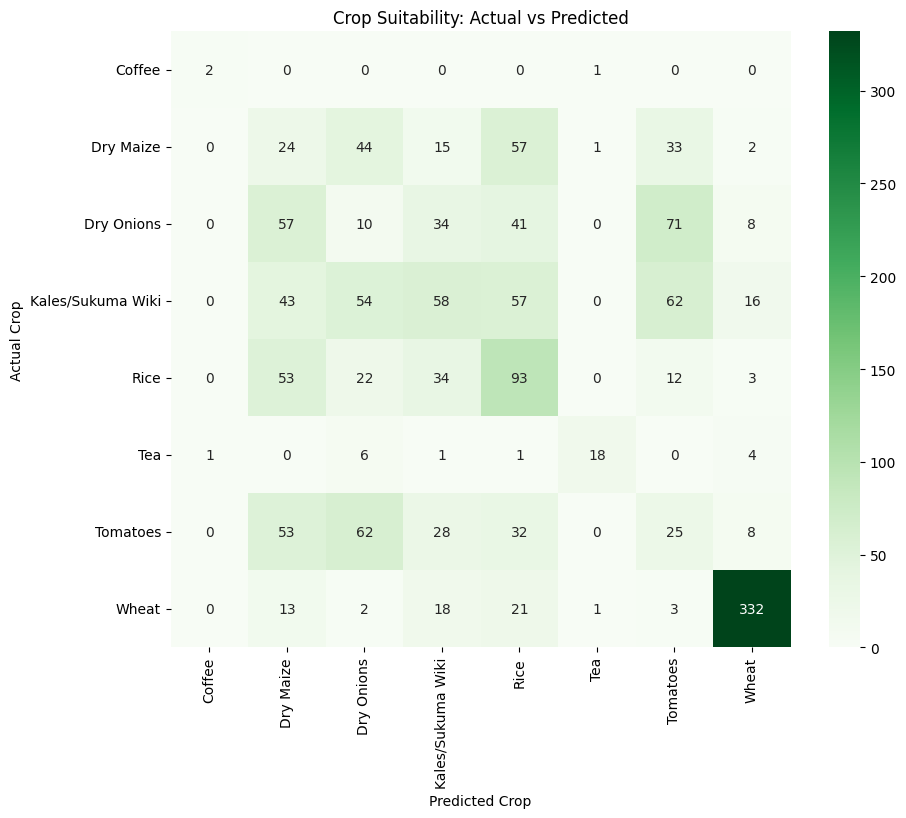

In [29]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Split your data (if you haven't already)
X_train, X_test, y_train, y_test = train_test_split(X_suit, y_suit, test_size=0.2, random_state=42)

# 2. Re-fit on training data and predict on test data
xgb_model = xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, objective='multi:softprob')
xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)

# 3. Print Accuracy Metrics
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 4. Plot Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=crop_mapping.keys(), 
            yticklabels=crop_mapping.keys())
plt.title('Crop Suitability: Actual vs Predicted')
plt.ylabel('Actual Crop')
plt.xlabel('Predicted Crop')
plt.show()

In [30]:
# --- LSTM: ECONOMIC FORECASTING ---
lstm_model = Sequential([
    LSTM(64, activation='relu', input_shape=(1, 5), return_sequences=True),
    Dropout(0.2),
    LSTM(32, activation='relu'),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(X_price_lstm, y_price, epochs=30, batch_size=32, verbose=0)

2026-03-11 08:04:12.395810: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/ushindi/AI/models/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [31]:
from sklearn.model_selection import train_test_split

# 1. Define your price features and target
# Features: Crop_ID, County_ID, Month, Year, Rainfall (Total 5 features)
price_features = ['Crop_Encoded', 'County_Encoded', 'Month', 'Year', 'Rainfall']
X_p = merged_df[price_features].values
y_p = merged_df['Wholesale'].values

# 2. Split the data (80% Train, 20% Test)
# We set shuffle=False because price trends follow a timeline
X_train_p, X_test_p, y_train, y_test = train_test_split(
    X_p, y_p, test_size=0.2, shuffle=False
)

# 3. Reshape to 3D: [Samples, Time_Steps, Features]
# Here, Time_Steps = 1 (we are looking at the current month's conditions)
X_train_lstm = X_train_p.reshape((X_train_p.shape[0], 1, X_train_p.shape[1]))
X_test_lstm = X_test_p.reshape((X_test_p.shape[0], 1, X_test_p.shape[1]))

print(f"X_train_lstm shape: {X_train_lstm.shape}") # Should be (Samples, 1, 5)
print("Data ready for training!")

X_train_lstm shape: (6141, 1, 5)
Data ready for training!


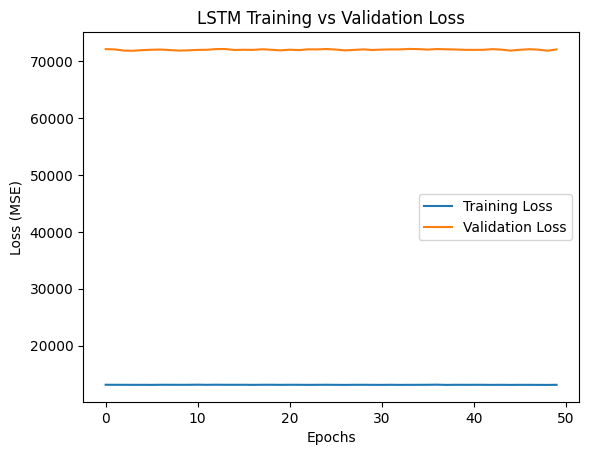

In [32]:
# 1. Train while capturing history
history = lstm_model.fit(
    X_train_lstm, y_train, 
    epochs=50, 
    batch_size=32, 
    validation_data=(X_test_lstm, y_test), 
    verbose=0
)

# 2. Plot the Learning Curve
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

In [34]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_absolute_percentage_error

# 1. Make Predictions
price_preds = lstm_model.predict(X_test_lstm)

# 2. Calculate Evaluation Metrics
mae = mean_absolute_error(y_test, price_preds)
r2 = r2_score(y_test, price_preds)
mape = mean_absolute_percentage_error(y_test, price_preds)

print(f"--- LSTM Price Model Evaluation ---")
print(f"Mean Absolute Error: KES {mae:.2f}") # Average error in Shillings
print(f"R-squared Score: {r2:.4f}")         # Closer to 1.0 is better
print(f"Accuracy (1-MAPE): {(1 - mape)*100:.2f}%")

48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
--- LSTM Price Model Evaluation ---
Mean Absolute Error: KES 34.36
R-squared Score: -0.0064
Accuracy (1-MAPE): 62.01%


In [38]:
def recommend_smart_crop(temp_max, temp_min, rainfall, humidity, soil_ph, county_name):
    county_enc = county_mapping[county_name]
    month, year = 5, 2026 # Example current date
    
    # A. Feature Engineering for Input
    temp_range = temp_max - temp_min
    rain_per_temp = rainfall / (temp_max + 1)
    avg_temp = (temp_max + temp_min) / 2
    
    # B. Get XGBoost Probabilities
    input_df = pd.DataFrame([[temp_max, temp_min, temp_range, rainfall, humidity, 
                               soil_ph, county_enc, month, rain_per_temp]], columns=suit_features)
    input_scaled = scaler.transform(input_df)
    suit_probs = xgb_model.predict_proba(input_scaled)[0]
    
    results = []
    
    # C. Loop through crops and apply the "Biological Shield"
    for crop_name, crop_id in crop_mapping.items():
        # 1. HARD CONSTRAINT CHECK (Using your Requirements Dataset)
        if crop_name in crop_limits:
            limits = crop_limits[crop_name]
            if not (limits['Min_Temp'] <= avg_temp <= limits['Max_Temp']): continue
            if not (limits['Min_Rain'] <= rainfall <= limits['Max_Rain']): continue
            if not (limits['Min_pH'] <= soil_ph <= limits['Max_pH']): continue
        
        # 2. PRICE PREDICTION (LSTM)
        price_input = np.array([[crop_id, county_enc, month, year, rainfall]]).reshape((1, 1, 5))
        pred_price = lstm_model.predict(price_input, verbose=0)[0][0]
        
        # 3. SCORING
        prob = suit_probs[crop_id]
        final_score = prob * pred_price
        
        if prob > 0.05: # Only show crops with at least 5% suitability
            results.append({
                'Crop': crop_name,
                'Suitability': f"{prob*100:.1f}%",
                'Predicted_Price': round(float(pred_price), 2),
                'Score': final_score
            })
            
    return sorted(results, key=lambda x: x['Score'], reverse=True)

# TEST: Now Wheat in Kilifi will be blocked by the 'if' statement!
# print(recommend_smart_crop(31, 24, 400, 70, 6.5, 'kilifi'))
# print(recommend_smart_crop(24, 13, 1200, 80, 5.8, 'kirinyaga'))
# print(recommend_smart_crop(25, 12, 900, 65, 6.8, 'uasin gishu'))
# print(recommend_smart_crop(24, 13, 600, 60, 6.7, 'nairobi'))
# print(recommend_smart_crop(31, 25, 700, 80, 7.2, 'mombasa'))
# print(recommend_smart_crop(26, 16, 1300, 75, 5.8, 'meru'))

[{'Crop': 'Kales/Sukuma Wiki', 'Suitability': '17.6%', 'Predicted_Price': 60.02, 'Score': np.float32(10.5353155)}]
